## Evaluation results visualization

This section loads the CSV files generated by `evaluation/main.py` and visualizes:

- System-level comparison (`summary_all_systems.csv`)
- Per-track distributions (`*.per_track.csv`)
- Onset vs note F1 relationships

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Slightly larger fonts for all subsequent plots
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.titlesize": 16,
})

repo_root = Path.cwd()
if not (repo_root / "evaluation").exists() and (repo_root.parent / "evaluation").exists():
    repo_root = repo_root.parent

results_dir = repo_root / "evaluation" / "results"
summary_path = results_dir / "summary_all_systems.csv"

print("Repo root:", repo_root)
print("Results dir:", results_dir)
print("Summary exists:", summary_path.exists())

Repo root: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir
Results dir: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/evaluation/results
Summary exists: True


In [2]:
summary_df = pd.read_csv(summary_path)
summary_df = summary_df.sort_values("note_f1", ascending=False).reset_index(drop=True)
summary_df

,system,est_dir,n_pairs,onset_f1,note_f1,mir_eval_note_f1,voicing_f1,voicing_accuracy,onset_precision,onset_recall,note_precision,note_recall,mir_eval_note_precision,mir_eval_note_recall,voicing_precision,voicing_recall
0,baseline_f0_cante_transcription,/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mi...,20,0.781783,0.424539,0.426888,0.833293,0.844213,0.771692,0.809648,0.419835,0.438271,0.419831,0.443759,0.837449,0.838752
1,demucs_PESTO_cante_transcription,/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mi...,20,0.808517,0.401569,0.397252,0.841471,0.851625,0.804842,0.816986,0.399366,0.406034,0.396029,0.400856,0.888740,0.810114
2,spleeter_PESTO_cante_transcription,/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mi...,20,0.786290,0.366322,0.392647,0.825366,0.836890,0.779198,0.801334,0.362254,0.373972,0.388594,0.400549,0.879660,0.795233
3,demucs_PESTO_transcription,/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mi...,20,0.523997,0.123666,0.126762,0.865292,0.869138,0.362845,0.975705,0.086473,0.223279,0.088515,0.228957,0.842312,0.899714
4,baseline_f0_transcription,/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mi...,20,0.469510,0.115349,0.112657,0.741824,0.741127,0.319588,0.949662,0.078812,0.228500,0.075871,0.234182,0.640618,0.907738
5,spleeter_PESTO_transcription,/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mi...,20,0.492935,0.114599,0.142861,0.823993,0.826186,0.336680,0.958410,0.078775,0.217258,0.098389,0.268595,0.797897,0.874504


### Cante-only grouped bar chart

Same three metrics as above, but only for systems ending in `_canteTranscription`, grouped by metric.

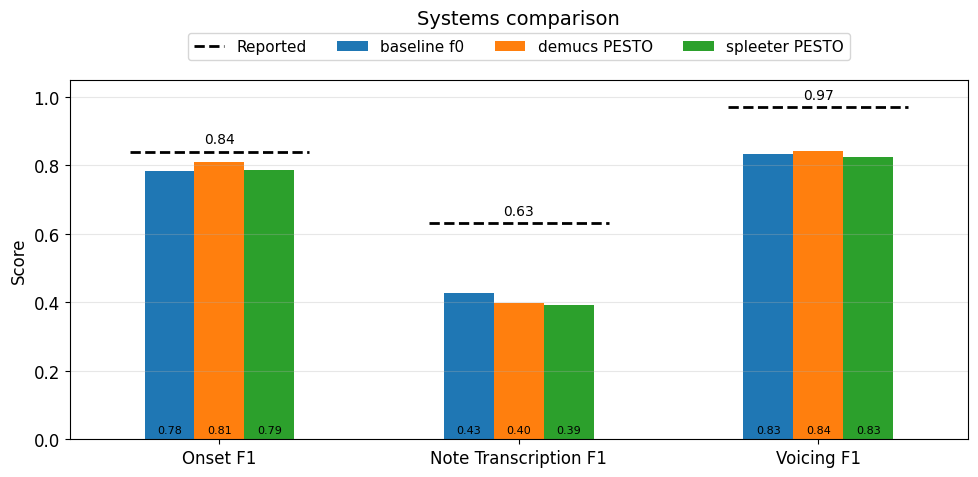

In [3]:
# Cante-only grouped bar chart: bars grouped by metric
metrics = ["onset_f1", "mir_eval_note_f1", "voicing_f1"]

cante_df = summary_df[summary_df["system"].str.endswith("_cante_transcription")].copy()
if cante_df.empty:
    raise ValueError("No systems ending with '_cante_transcription' found in summary_all_systems.csv")

system_order = [s for s in summary_df["system"].tolist() if s in set(cante_df["system"])]

long_df = cante_df.melt(
    id_vars="system",
    value_vars=metrics,
    var_name="metric",
    value_name="score",
)

grouped = long_df.pivot(index="metric", columns="system", values="score")
grouped = grouped.loc[metrics, system_order]

# Clean legend labels
grouped = grouped.rename(
    columns=lambda s: s.replace("_cante_transcription", "")
                .replace("_transcription", "")
                .replace("_", " ")
)

metric_labels = {
    "onset_f1": "Onset F1",
    "mir_eval_note_f1": "Note Transcription F1",
    "voicing_f1": "Voicing F1",
}

reported = {
    "onset_f1": 0.84,
    "mir_eval_note_f1": 0.63,
    "voicing_f1": 0.97,
}

display_metrics = [metric_labels[m] for m in metrics]
grouped.index = display_metrics

ax = grouped.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Systems comparison", pad=40)
#ax.set_xlabel("Metric")
ax.set_ylabel("Score")
y_top = max(float(grouped.max().max()), max(reported.values())) + 0.08
ax.set_ylim(0, min(1.10, y_top))
ax.grid(axis="y", alpha=0.3)

# Add reported metric reference lines on top of each metric group
for i, metric in enumerate(metrics):
    y = reported[metric]
    ax.hlines(
        y=y,
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="black",
        linestyles="--",
        linewidth=2,
        label="Reported" if i == 0 else None,
        zorder=5,
    )
    y_text = min(y + 0.015, ax.get_ylim()[1] - 0.01)
    ax.text(i, y_text, f"{y:.2f}", ha="center", va="bottom", fontsize=10)

# Add small values at the bottom of each bar
for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h != h:
            continue
        x = bar.get_x() + bar.get_width() / 2
        ax.text(x, 0.012, f"{h:.2f}", ha="center", va="bottom", fontsize=8)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=4, frameon=True)
plt.tight_layout()
plt.show()

In [4]:
# Load all per-track files and concatenate
per_track_paths = sorted(results_dir.glob("*.per_track.csv"))
frames = []
for p in per_track_paths:
    df = pd.read_csv(p)
    df["system"] = p.name.replace(".per_track.csv", "")
    frames.append(df)

per_track_df = pd.concat(frames, ignore_index=True)
print("Per-track rows:", len(per_track_df))
per_track_df[["track", "system", "onset_f1", "note_f1", "mir_eval_note_f1"]].head()

Per-track rows: 120


,track,system,onset_f1,note_f1,mir_eval_note_f1
0,01_GabrielMoreno_YoNoTeHeDaoMotivos,baseline_f0_cante_transcription,0.815657,0.429293,0.436869
1,02_BernardoElDeLosLobitos_LosPecesMueranDePena,baseline_f0_cante_transcription,0.619503,0.305927,0.340344
2,03_BernardoElDeLosLobitos_PorLasTrenzasDeTuPelo,baseline_f0_cante_transcription,0.732584,0.319101,0.382022
3,04_AngelDeAlora_LosCaminosEstanMuyMalos,baseline_f0_cante_transcription,0.822917,0.375000,0.380208
4,05_Antonio Mairena_Verguenza,baseline_f0_cante_transcription,0.824926,0.510386,0.504451


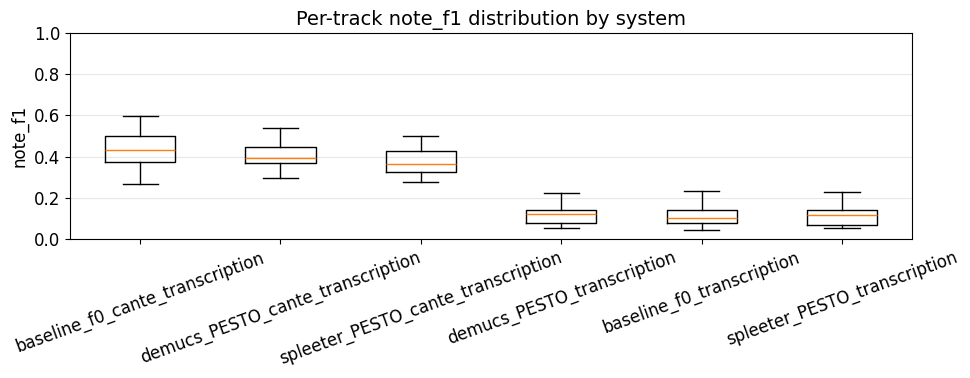

In [5]:
# Boxplot: per-track note_f1 by system
plt.figure(figsize=(10, 4))
order = summary_df["system"].tolist()
box_data = [per_track_df.loc[per_track_df["system"] == s, "note_f1"].dropna().values for s in order]

plt.boxplot(box_data, tick_labels=order, showfliers=False)
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.ylabel("note_f1")
plt.title("Per-track note_f1 distribution by system")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

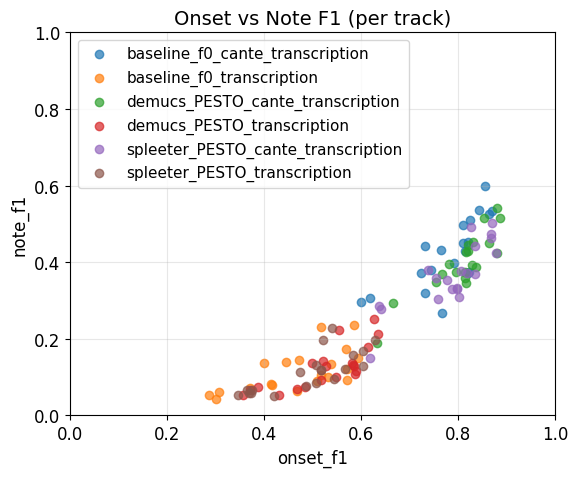

In [6]:
# Scatter: onset_f1 vs note_f1 by system (per track)
plt.figure(figsize=(6, 5))
for system, g in per_track_df.groupby("system"):
    plt.scatter(g["onset_f1"], g["note_f1"], alpha=0.7, label=system)

plt.xlabel("onset_f1")
plt.ylabel("note_f1")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Onset vs Note F1 (per track)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Pitch distribution relative to ground-truth track median

For each transcription system, the plot below shows the distribution of estimated MIDI pitch values after centering each track by the ground-truth median pitch:

$\Delta\text{MIDI} = \text{MIDI}_{\text{est}} - \mathrm{median}(\text{MIDI}_{\text{ground truth, same track}})$

The histograms are normalized (density), so systems can be compared even if the number of notes differs.

Rows: 18461
Systems: 3
['baseline_f0_cante_transcription', 'demucs_PESTO_cante_transcription', 'spleeter_PESTO_cante_transcription']


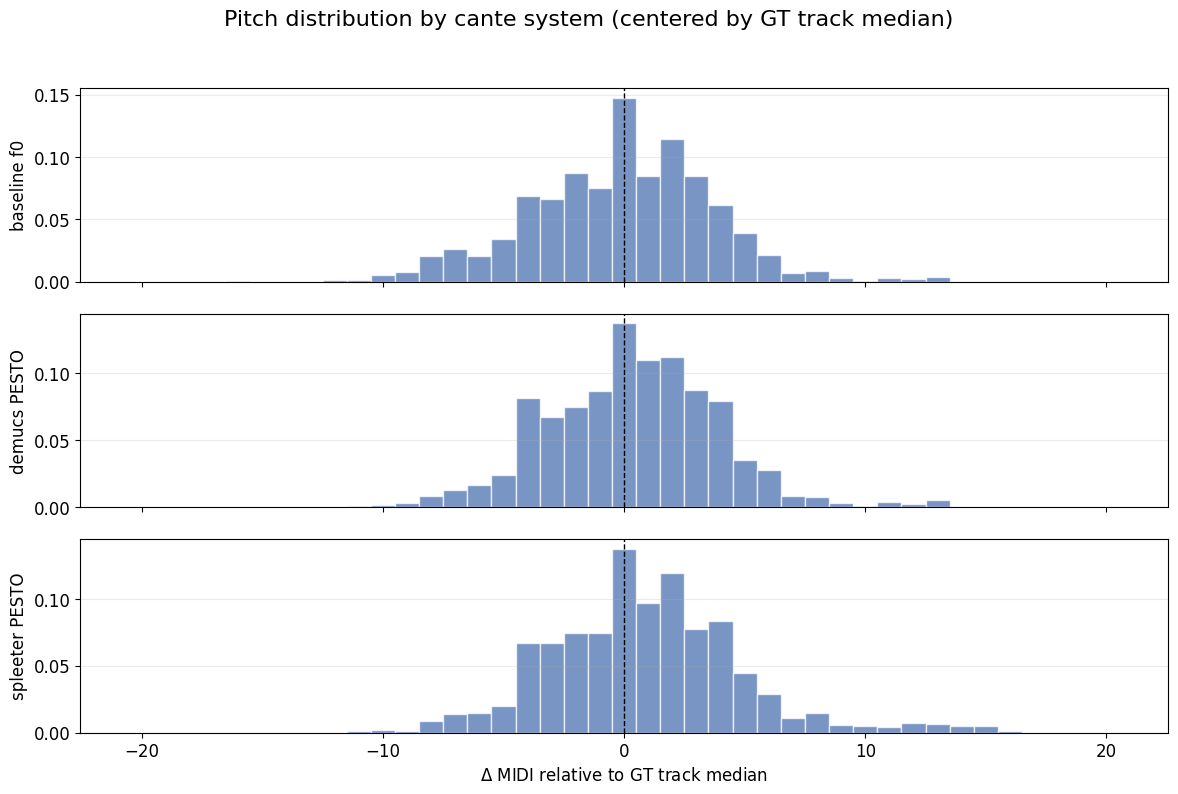

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from evaluate_onset_note_transcription import load_notes_file

def normalize_track_id(path: Path) -> str:
    name = path.name
    for suffix in (".notes.csv", ".notes", ".csv"):
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return path.stem

def is_cante_system(name: str) -> bool:
    n = name.lower()
    return n.endswith("_cantetranscription") or n.endswith("_cante_transcription")

def clean_system_label(name: str) -> str:
    return (
        name.replace("_canteTranscription", "")
            .replace("_cante_transcription", "")
            .replace("_transcription", "")
            .replace("_", " ")
    )

def collect_system_pitch_offsets(ref_dir: Path, est_dir: Path) -> pd.DataFrame:
    ref_files = sorted(list(ref_dir.glob("*.notes")) + list(ref_dir.glob("*.csv")))
    est_files = sorted(
        list(est_dir.glob("*.notes.csv"))
        + list(est_dir.glob("*.notes"))
        + list(est_dir.glob("*.csv"))
    )

    ref_map = {normalize_track_id(p): p for p in ref_files}
    est_map = {normalize_track_id(p): p for p in est_files}
    common_ids = sorted(set(ref_map) & set(est_map))

    rows = []
    for tid in common_ids:
        ref = load_notes_file(ref_map[tid])
        est = load_notes_file(est_map[tid])
        if len(ref.midi) == 0 or len(est.midi) == 0:
            continue

        gt_median = float(np.median(ref.midi))
        for midi_val in est.midi:
            rows.append(
                {
                    "track": tid,
                    "gt_median_midi": gt_median,
                    "est_midi": float(midi_val),
                    "offset_to_gt_median": float(midi_val) - gt_median,
                }
            )

    return pd.DataFrame(rows)

ref_dir = repo_root / "data" / "cante2midi_groundTruth"
est_root = repo_root / "noteTranscription"
system_dirs = sorted(
    [
        p for p in est_root.iterdir()
        if p.is_dir() and is_cante_system(p.name) and not p.name.startswith("__")
    ]
)

all_offsets = []
for system_dir in system_dirs:
    df = collect_system_pitch_offsets(ref_dir, system_dir)
    if df.empty:
        continue
    df["system"] = system_dir.name
    all_offsets.append(df)

pitch_offset_df = pd.concat(all_offsets, ignore_index=True) if all_offsets else pd.DataFrame()
print("Rows:", len(pitch_offset_df))
print("Systems:", pitch_offset_df["system"].nunique() if not pitch_offset_df.empty else 0)
if not pitch_offset_df.empty:
    print(sorted(pitch_offset_df["system"].unique().tolist()))

if pitch_offset_df.empty:
    raise ValueError("No cante pitch data found. Check ground-truth and transcription folders.")

if "summary_df" in globals() and "system" in summary_df.columns:
    order = [s for s in summary_df["system"].tolist() if s in set(pitch_offset_df["system"])]
else:
    order = sorted(pitch_offset_df["system"].unique().tolist())

max_abs = float(np.nanmax(np.abs(pitch_offset_df["offset_to_gt_median"])))
max_abs = int(np.clip(np.ceil(max_abs), 12, 36))
bins = np.arange(-max_abs - 0.5, max_abs + 1.5, 1.0)

n_systems = len(order)
fig, axes = plt.subplots(n_systems, 1, figsize=(12, max(2.6 * n_systems, 4.5)), sharex=True)
if n_systems == 1:
    axes = [axes]

for ax, system in zip(axes, order):
    vals = pitch_offset_df.loc[pitch_offset_df["system"] == system, "offset_to_gt_median"].dropna().values
    ax.hist(vals, bins=bins, density=True, alpha=0.75, color="#4c72b0", edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_ylabel(clean_system_label(system))
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel(r"$\Delta$ MIDI relative to GT track median")
fig.suptitle("Pitch distribution by cante system (centered by GT track median)", y=1.02)
plt.tight_layout()
plt.show()

Series: ['groundtruth', 'baseline_f0_cante_transcription', 'demucs_PESTO_cante_transcription', 'spleeter_PESTO_cante_transcription']


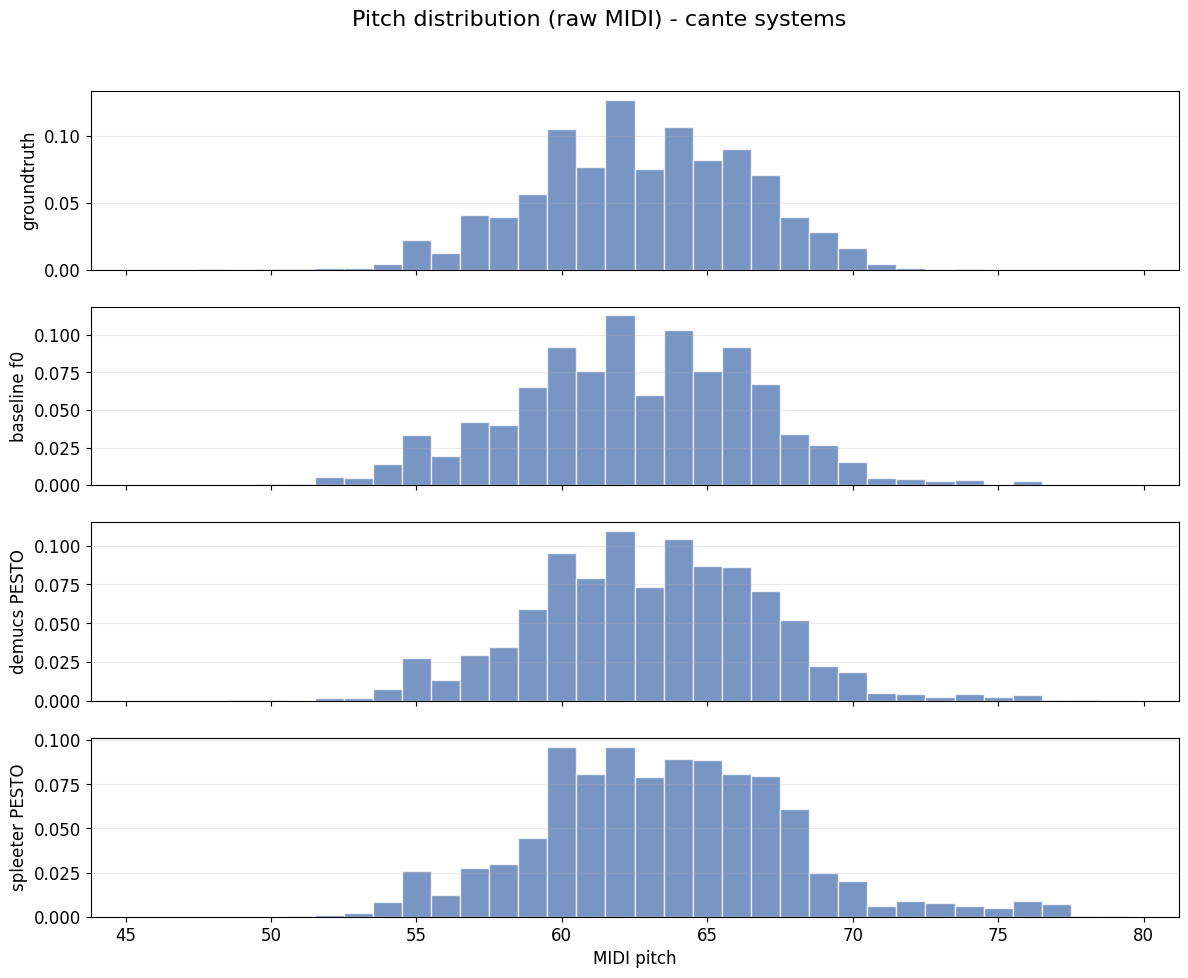

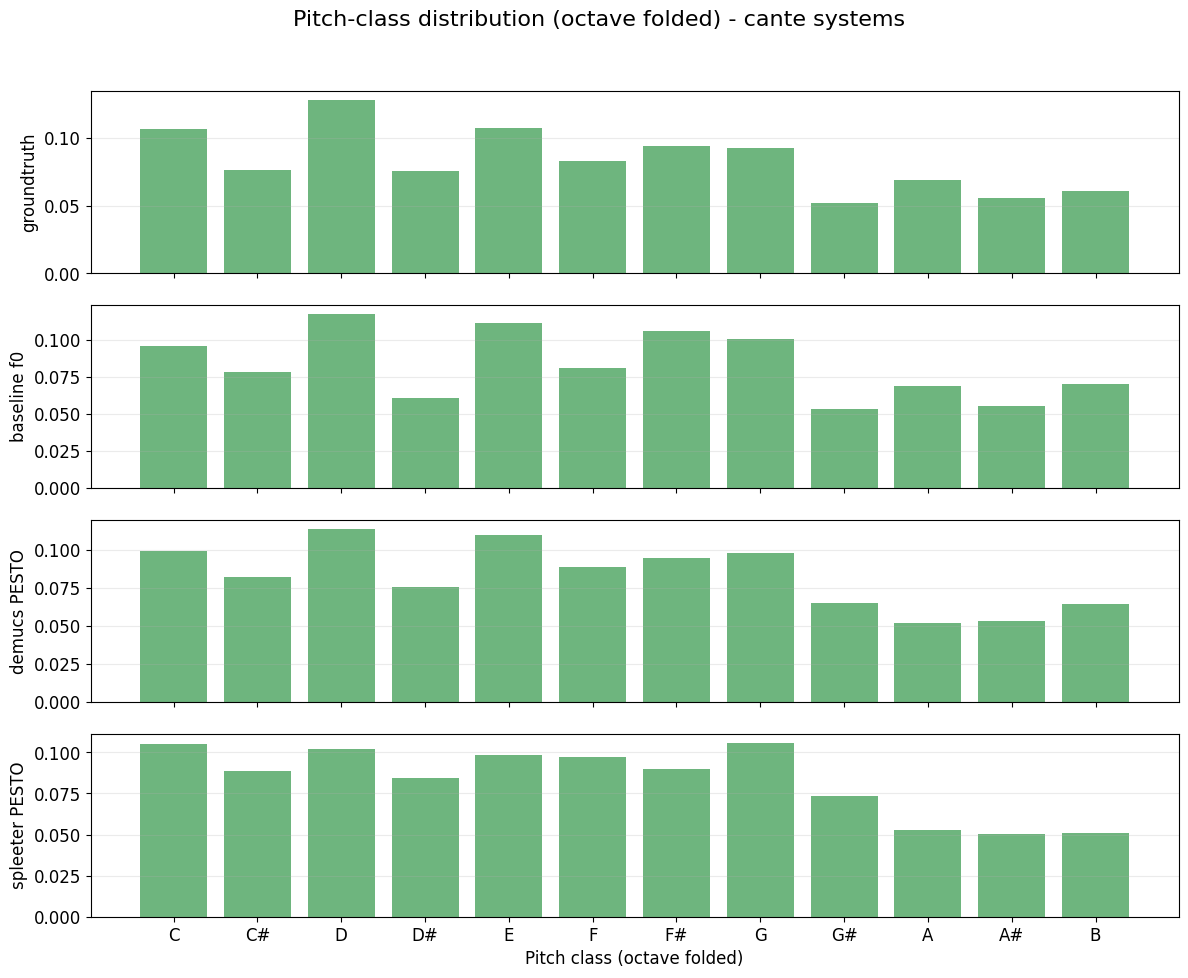

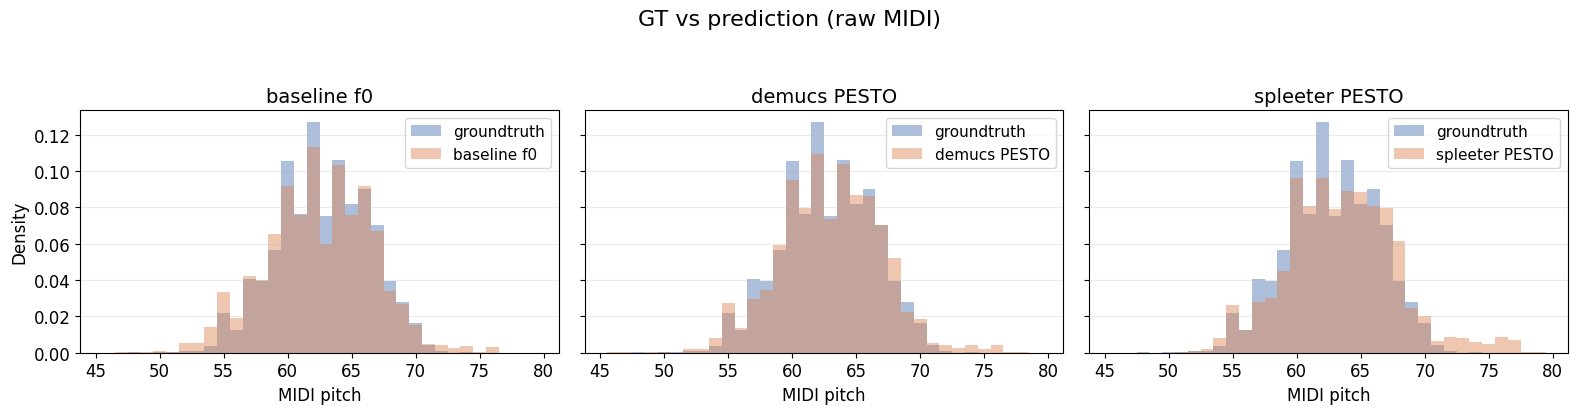

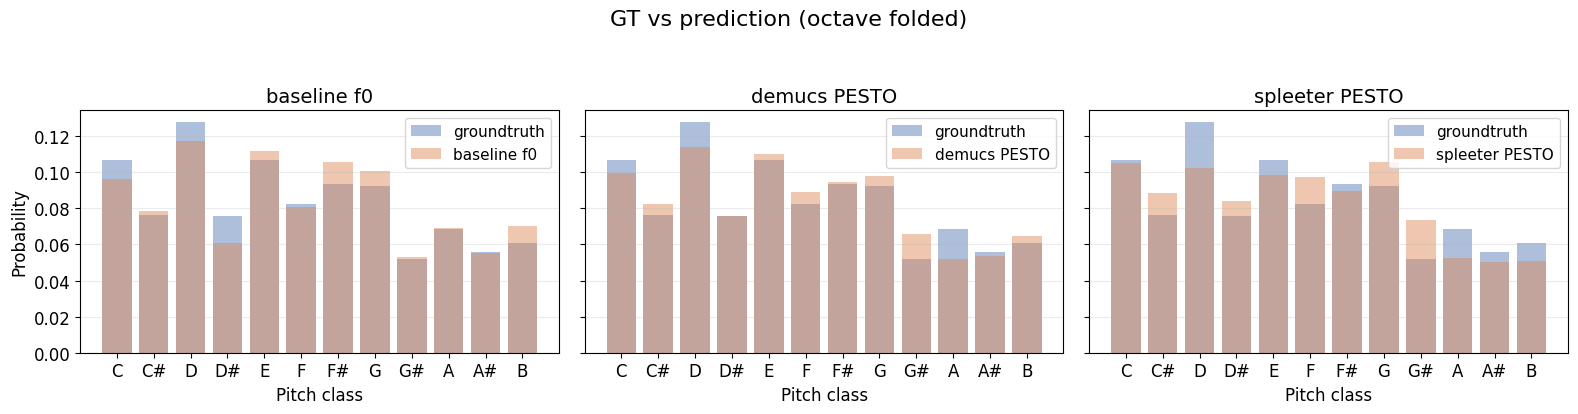

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from evaluate_onset_note_transcription import load_notes_file

def normalize_track_id(path: Path) -> str:
    name = path.name
    for suffix in (".notes.csv", ".notes", ".csv"):
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return path.stem

def is_cante_system(name: str) -> bool:
    n = name.lower()
    return n.endswith("_cantetranscription") or n.endswith("_cante_transcription")

def clean_system_label(name: str) -> str:
    return (
        name.replace("_canteTranscription", "")
            .replace("_cante_transcription", "")
            .replace("_transcription", "")
            .replace("_", " ")
    )

def method_key_from_system(system_name: str) -> str:
    base = clean_system_label(system_name).lower().replace(" ", "")
    if "baseline" in base:
        return "baseline_f0"
    if "demucs" in base:
        return "demucs_PESTO"
    if "spleeter" in base:
        return "spleeter_PESTO"
    return clean_system_label(system_name)

def get_pitch_array(path: Path) -> np.ndarray:
    notes = load_notes_file(path)
    return notes.midi.astype(float) if len(notes.midi) else np.array([], dtype=float)

def collect_system_and_gt_pitches(ref_dir: Path, est_dir: Path) -> tuple[np.ndarray, np.ndarray]:
    ref_files = sorted(list(ref_dir.glob("*.notes")) + list(ref_dir.glob("*.csv")))
    est_files = sorted(
        list(est_dir.glob("*.notes.csv"))
        + list(est_dir.glob("*.notes"))
        + list(est_dir.glob("*.csv"))
    )

    ref_map = {normalize_track_id(p): p for p in ref_files}
    est_map = {normalize_track_id(p): p for p in est_files}
    common_ids = sorted(set(ref_map) & set(est_map))

    gt_vals = []
    est_vals = []
    for tid in common_ids:
        gt_arr = get_pitch_array(ref_map[tid])
        est_arr = get_pitch_array(est_map[tid])
        if gt_arr.size:
            gt_vals.append(gt_arr)
        if est_arr.size:
            est_vals.append(est_arr)

    gt_concat = np.concatenate(gt_vals) if gt_vals else np.array([], dtype=float)
    est_concat = np.concatenate(est_vals) if est_vals else np.array([], dtype=float)
    return gt_concat, est_concat

ref_dir = repo_root / "data" / "cante2midi_groundTruth"
est_root = repo_root / "noteTranscription"
system_dirs = sorted(
    [
        p for p in est_root.iterdir()
        if p.is_dir() and is_cante_system(p.name) and not p.name.startswith("__")
    ]
)

series = {}

# Ground truth over the full reference set
ref_files = sorted(list(ref_dir.glob("*.notes")) + list(ref_dir.glob("*.csv")))
gt_all = []
for p in ref_files:
    arr = get_pitch_array(p)
    if arr.size:
        gt_all.append(arr)
series["groundtruth"] = np.concatenate(gt_all) if gt_all else np.array([], dtype=float)

# Each cante transcription system, matched to GT by track id
for system_dir in system_dirs:
    _, est_concat = collect_system_and_gt_pitches(ref_dir, system_dir)
    if est_concat.size:
        series[system_dir.name] = est_concat

labels = list(series.keys())
print("Series:", labels)

# 1) Raw MIDI pitch distributions (cante systems only + groundtruth)
all_vals = np.concatenate([v for v in series.values() if v.size])
min_midi = int(np.floor(all_vals.min()))
max_midi = int(np.ceil(all_vals.max()))
bins = np.arange(min_midi - 0.5, max_midi + 1.5, 1.0)

n = len(labels)
fig, axes = plt.subplots(n, 1, figsize=(12, max(2.4 * n, 5)), sharex=True)
if n == 1:
    axes = [axes]

for ax, label in zip(axes, labels):
    vals = series[label]
    ax.hist(vals, bins=bins, density=True, alpha=0.75, color="#4c72b0", edgecolor="white")
    shown_label = "groundtruth" if label == "groundtruth" else clean_system_label(label)
    ax.set_ylabel(shown_label)
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("MIDI pitch")
fig.suptitle("Pitch distribution (raw MIDI) - cante systems", y=1.02)
plt.tight_layout()
plt.show()

# 2) Octave-folded distributions (pitch classes)
pc_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
x = np.arange(12)

fig, axes = plt.subplots(n, 1, figsize=(12, max(2.4 * n, 5)), sharex=True)
if n == 1:
    axes = [axes]

for ax, label in zip(axes, labels):
    vals = series[label]
    pitch_class = np.mod(np.round(vals).astype(int), 12)
    counts = np.bincount(pitch_class, minlength=12).astype(float)
    probs = counts / counts.sum() if counts.sum() > 0 else counts
    ax.bar(x, probs, color="#55a868", alpha=0.85)
    shown_label = "groundtruth" if label == "groundtruth" else clean_system_label(label)
    ax.set_ylabel(shown_label)
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(pc_names)
axes[-1].set_xlabel("Pitch class (octave folded)")
fig.suptitle("Pitch-class distribution (octave folded) - cante systems", y=1.02)
plt.tight_layout()
plt.show()

# 3) 3-subplot overlay: GT vs each methodology (raw MIDI)
method_order = ["baseline_f0", "demucs_PESTO", "spleeter_PESTO"]
method_series = {}
for k, vals in series.items():
    if k == "groundtruth":
        continue
    mk = method_key_from_system(k)
    if mk in method_order and mk not in method_series:
        method_series[mk] = vals

gt_vals = series["groundtruth"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, method in zip(axes, method_order):
    pred_vals = method_series.get(method, np.array([], dtype=float))
    ax.hist(gt_vals, bins=bins, density=True, alpha=0.45, color="#4c72b0", label="groundtruth")
    if pred_vals.size:
        ax.hist(pred_vals, bins=bins, density=True, alpha=0.45, color="#dd8452", label=method.replace("_", " "))
    ax.set_title(method.replace("_", " "))
    ax.set_xlabel("MIDI pitch")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper right")
axes[0].set_ylabel("Density")
fig.suptitle("GT vs prediction (raw MIDI)", y=1.04)
plt.tight_layout()
plt.show()

# 4) 3-subplot overlay: GT vs each methodology (octave folded)
gt_pc = np.mod(np.round(gt_vals).astype(int), 12)
gt_counts = np.bincount(gt_pc, minlength=12).astype(float)
gt_probs = gt_counts / gt_counts.sum() if gt_counts.sum() > 0 else gt_counts

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, method in zip(axes, method_order):
    pred_vals = method_series.get(method, np.array([], dtype=float))
    if pred_vals.size:
        pred_pc = np.mod(np.round(pred_vals).astype(int), 12)
        pred_counts = np.bincount(pred_pc, minlength=12).astype(float)
        pred_probs = pred_counts / pred_counts.sum() if pred_counts.sum() > 0 else pred_counts
    else:
        pred_probs = np.zeros(12, dtype=float)

    ax.bar(x, gt_probs, alpha=0.45, color="#4c72b0", label="groundtruth")
    ax.bar(x, pred_probs, alpha=0.45, color="#dd8452", label=method.replace("_", " "))
    ax.set_title(method.replace("_", " "))
    ax.set_xticks(x)
    ax.set_xticklabels(pc_names)
    ax.set_xlabel("Pitch class")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper right")

axes[0].set_ylabel("Probability")
fig.suptitle("GT vs prediction (octave folded)", y=1.04)
plt.tight_layout()
plt.show()